In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

(np.float64(-0.5), np.float64(319.5), np.float64(239.5), np.float64(-0.5))

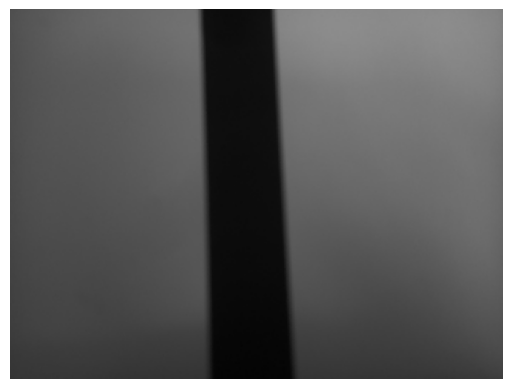

In [2]:
image = cv2.imread('line_1.jpg')
resized = cv2.resize(image, (320, 240))
gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
plt.imshow(cv2.cvtColor(gray, cv2.COLOR_BGR2RGB))
# hide axes
plt.axis('off')

(np.float64(-0.5), np.float64(319.5), np.float64(239.5), np.float64(-0.5))

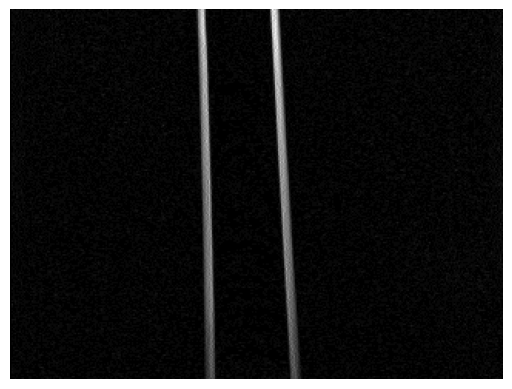

In [3]:
# Create an image from the horizontal pixel differences
diff = np.zeros(gray.shape, dtype=np.uint8)
for row in range(gray.shape[0]):
    for i in range(1, gray.shape[1]):
        diff[row, i] = abs(int(gray[row, i]) - int(gray[row, i - 1]))
# Normalise the difference image
diff = cv2.normalize(diff, None, 0, 255, cv2.NORM_MINMAX)
plt.imshow(cv2.cvtColor(diff, cv2.COLOR_BGR2RGB))
# hide axes
plt.axis('off')

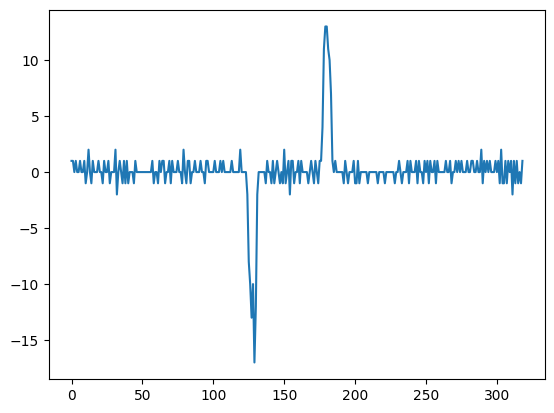

In [4]:
row = gray[180].astype(np.int32)
diff = np.diff(row)
plt.plot(diff)

(np.float64(-0.5), np.float64(319.5), np.float64(239.5), np.float64(-0.5))

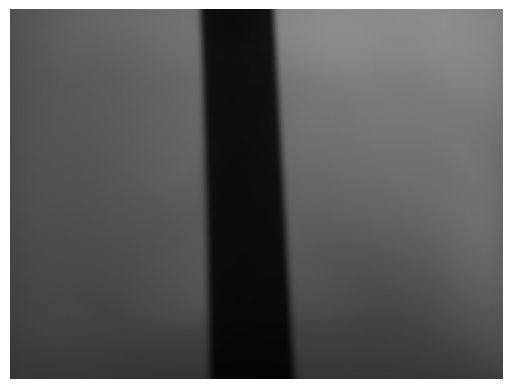

In [ ]:
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
diff = np.diff(row)
plt.plot(diff)

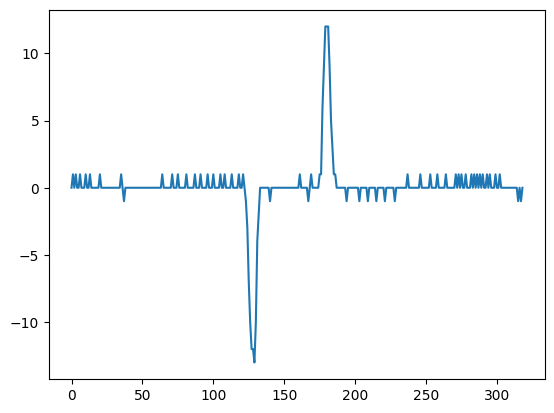

In [6]:
b_row = blurred[180].astype(np.int32)
b_diff = np.diff(b_row)
plt.plot(b_diff)

In [7]:
max_d = np.amax(b_diff)
min_d = np.amin(b_diff)
highest = np.where(b_diff == max_d)[0][0]
lowest = np.where(b_diff == min_d)[0][0]
middle = (highest + lowest) // 2

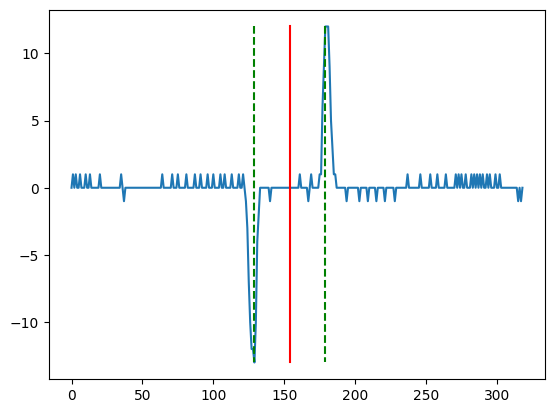

In [8]:
plt.plot(b_diff)
plt.plot([middle, middle], [max_d, min_d], "r-")
plt.plot([lowest, lowest], [max_d, min_d], "g--")
plt.plot([highest, highest], [max_d, min_d], "g--")


(np.float64(-0.5), np.float64(319.5), np.float64(239.5), np.float64(-0.5))

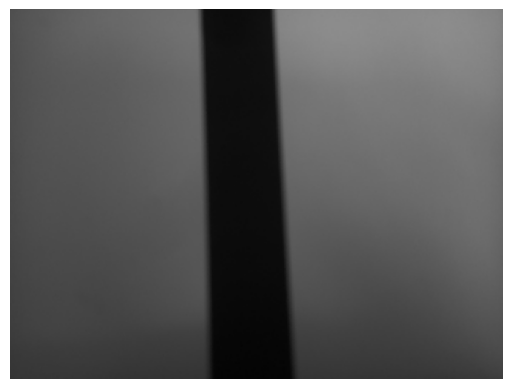

In [9]:
plt.imshow(cv2.cvtColor(gray, cv2.COLOR_BGR2RGB))
# hide axes
plt.axis('off')

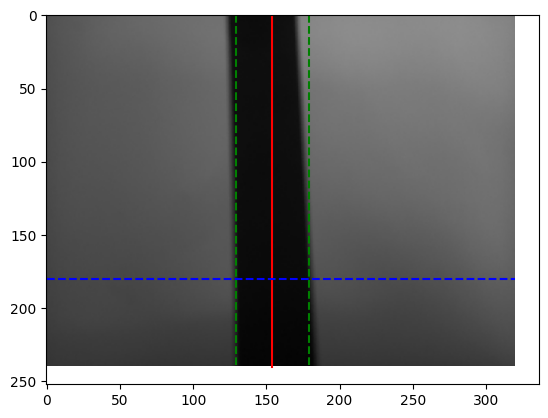

In [10]:
plt.imshow(cv2.cvtColor(gray, cv2.COLOR_BGR2RGB))
plt.plot([middle, middle], [0, 240], "r-")
plt.plot([lowest, lowest], [0, 240], "g--")
plt.plot([highest, highest], [0, 240], "g--")
plt.plot([0, 320], [180, 180], "b--")

In [11]:
class LineFinder:
    def __init__(self, image, row_number):
        self.image = image
        self.gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        self.blurred = cv2.blur(self.gray, (9, 9), 0)
        # self.blurred = cv2.blur(self.blurred, (5, 5), 0)
        row = self.blurred[row_number].astype(np.int32)
        self.diff = np.diff(row)

        max_d = np.amax(self.diff)
        min_d = np.amin(self.diff)
        self.highest = np.where(self.diff == max_d)[0][0]
        self.lowest = np.where(self.diff == min_d)[0][0]
        self.stddev = np.std(self.diff)
        if max_d < 3 * self.stddev:
            self.highest = 0
            self.lowest = 320
        self.middle = (self.highest + self.lowest) // 2

    def plot_image(self):
        plt.imshow(cv2.cvtColor(self.blurred, cv2.COLOR_BGR2RGB))
        # plt.imshow(cv2.cvtColor(self.image, cv2.COLOR_BGR2RGB))
        plt.plot([self.middle, self.middle], [0, 240], "r-")
        plt.plot([self.lowest, self.lowest], [0, 240], "g--")
        plt.plot([self.highest, self.highest], [0, 240], "g--")
        plt.plot([0, 320], [180, 180], "b--")
    
    def plot_diff(self):
        # Set the 
        plt.plot(self.diff)
        plt.plot([self.middle, self.middle], [np.amax(self.diff), np.amin(self.diff)], "r-")
        plt.plot([self.lowest, self.lowest], [np.amax(self.diff), np.amin(self.diff)], "g--")
        plt.plot([self.highest, self.highest], [np.amax(self.diff), np.amin(self.diff)], "g--")
        # Plot the standard deviation line
        plt.axhline(y=self.stddev, color='orange', linestyle='--', label='Std Dev')
        # Plot 3x the standard deviation line
        plt.axhline(y=3 * self.stddev, color='red', linestyle='--', label='3x Std Dev')

    def plot_both(self):
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        self.plot_image()
        plt.title('Line Finder Image Plot')
        plt.subplot(1, 2, 2)
        self.plot_diff()
        # set the height of the diff plot to match the image plot
        plt.ylim(-20, 20)
        
        plt.title('Line Finder Diff Plot')
        plt.tight_layout()
        plt.show()
    


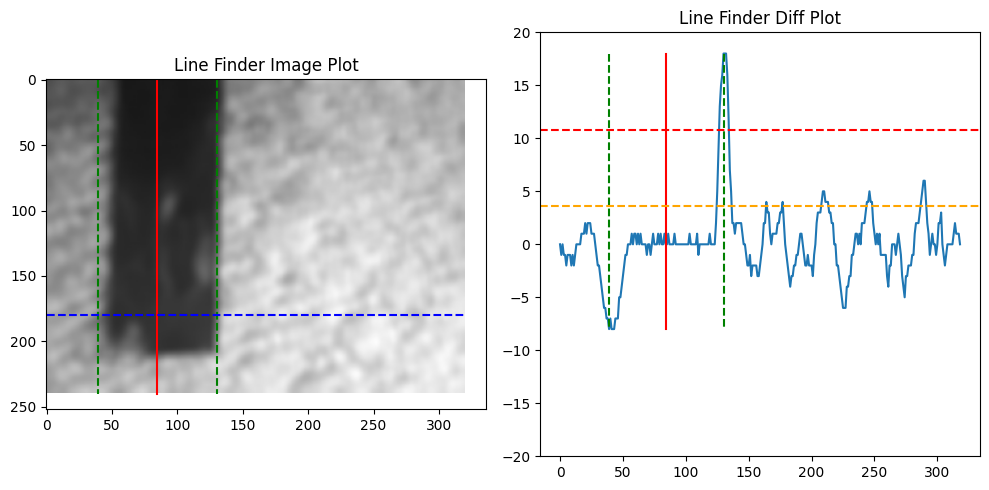

In [12]:
carpet_line = cv2.imread('carpet_line1 2.jpg')
carpet_line = cv2.resize(carpet_line, (320, 240))
line = LineFinder(carpet_line, 180)
line.plot_both()

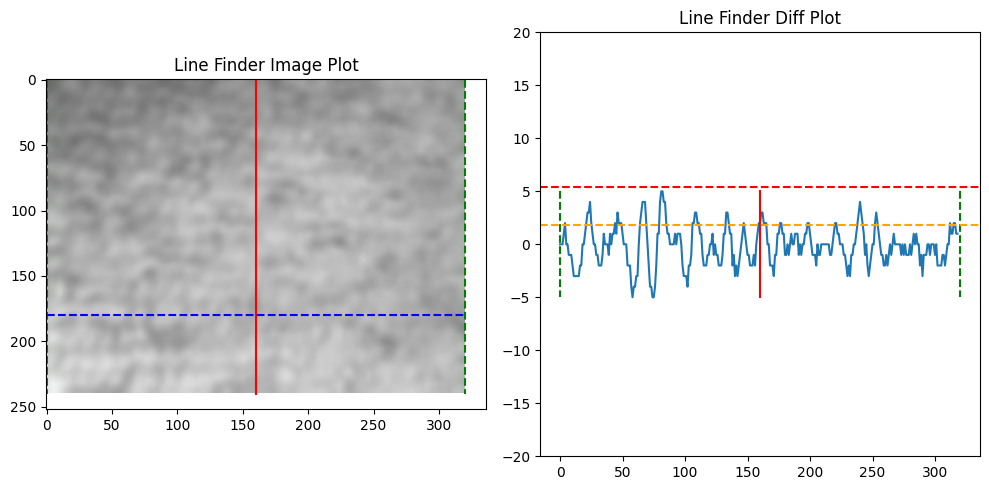

In [13]:
image = cv2.imread('carpet_noline.jpg')
image = cv2.resize(image, (320, 240))
line = LineFinder(image, 180)
line.plot_both()

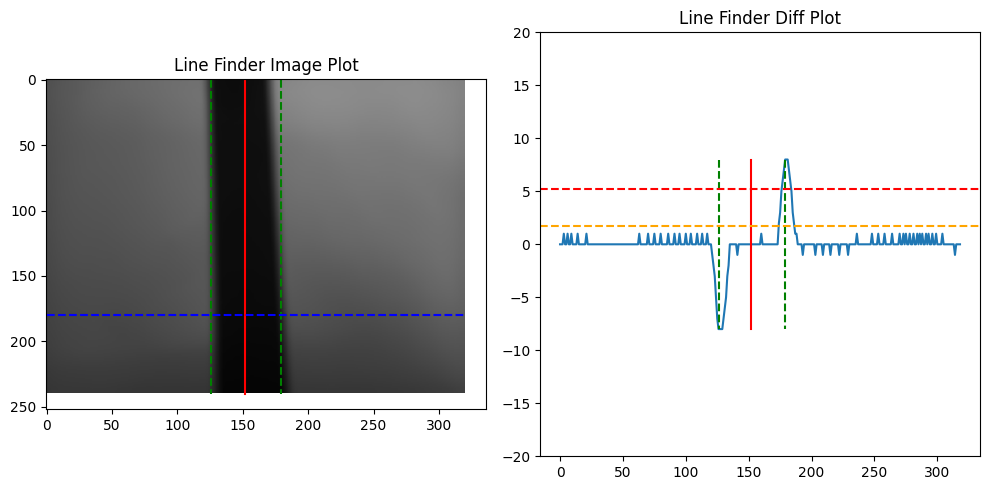

In [14]:
image = cv2.imread('line_1.jpg')
image = cv2.resize(image, (320, 240))
line = LineFinder(image, 180)
line.plot_both()

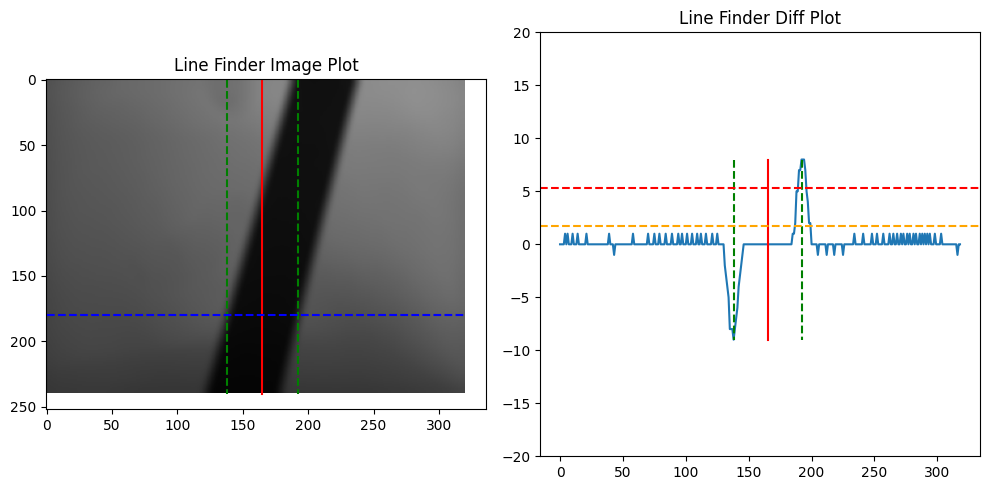

In [15]:
image = cv2.imread('line_2.jpg')
image = cv2.resize(image, (320, 240))
line = LineFinder(image, 180)
line.plot_both()

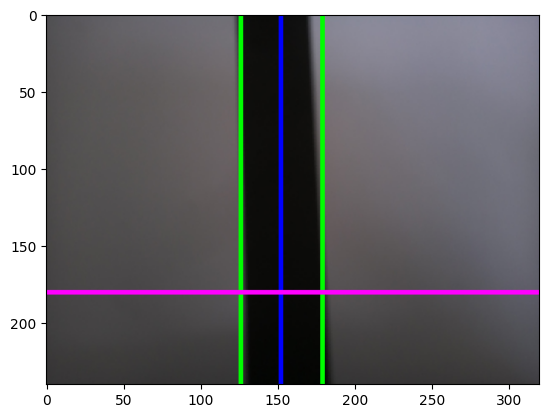

In [16]:
# Can we use CV2 to draw the lines on the image?
def draw_lines(image, line_finder):
    cv2.line(image, (line_finder.middle, 0), (line_finder.middle, 240), (255, 0, 0), 2)
    cv2.line(image, (line_finder.lowest, 0), (line_finder.lowest, 240), (0, 255, 0), 2)
    cv2.line(image, (line_finder.highest, 0), (line_finder.highest, 240), (0, 255, 0), 2)
    # add a horizontal line at row 180
    cv2.line(image, (0, 180), (320, 180), (255, 0, 255), 2)
    return image

image = cv2.imread('line_1.jpg')
image = cv2.resize(image, (320, 240))
line = LineFinder(image, 180)
image_with_lines = draw_lines(image.copy(), line)
plt.imshow(cv2.cvtColor(image_with_lines, cv2.COLOR_BGR2RGB))

In [17]:
class MultiRowLineFinder:
    def __init__(self, image, row_numbers):
        self.image = image
        self.gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        self.blurred = cv2.blur(self.gray, (9, 9), 0)
        self.rows = []
        for row_number in row_numbers:
            row = self.blurred[row_number].astype(np.int32)
            diff = np.diff(row)
            max_d = np.amax(diff)
            min_d = np.amin(diff)
            highest = np.where(diff == max_d)[0][0]
            lowest = np.where(diff == min_d)[0][0]
            self.stddev = np.std(diff)
            if max_d < 3 * self.stddev:
                highest = 0
                lowest = 320
            middle = (highest + lowest) // 2
            self.rows.append((row_number, middle, lowest, highest))

    def plot_image(self):
        plt.imshow(cv2.cvtColor(self.blurred, cv2.COLOR_BGR2RGB))
        for row_number, middle, lowest, highest in self.rows:
            plt.plot([middle, middle], [row_number - 20, row_number + 20], "r-")
            plt.plot([lowest, lowest], [row_number - 20, row_number + 20], "g--")
            plt.plot([highest, highest], [row_number - 20, row_number + 20], "g--")
            plt.plot([0, 320], [row_number, row_number], "b--")

    def plot_diff(self):
        for i, (row_number, middle, lowest, highest) in enumerate(self.rows):            
            diff = np.diff(self.blurred[row_number].astype(np.int32))
            plt.plot(diff)
            plt.plot([middle, middle], [np.amax(diff), np.amin(diff)], "r-")
            plt.plot([lowest, lowest], [np.amax(diff), np.amin(diff)], "g--")
            plt.plot([highest, highest], [np.amax(diff), np.amin(diff)], "g--")
        plt.ylim(-20, 20)

    def plot_both(self):
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        self.plot_image()
        plt.title('Multi Row Line Finder Image Plot')
        plt.subplot(1, 2, 2)
        self.plot_diff()
        plt.title('Multi Row Line Finder Diff Plot')
        plt.tight_layout()
        plt.show()

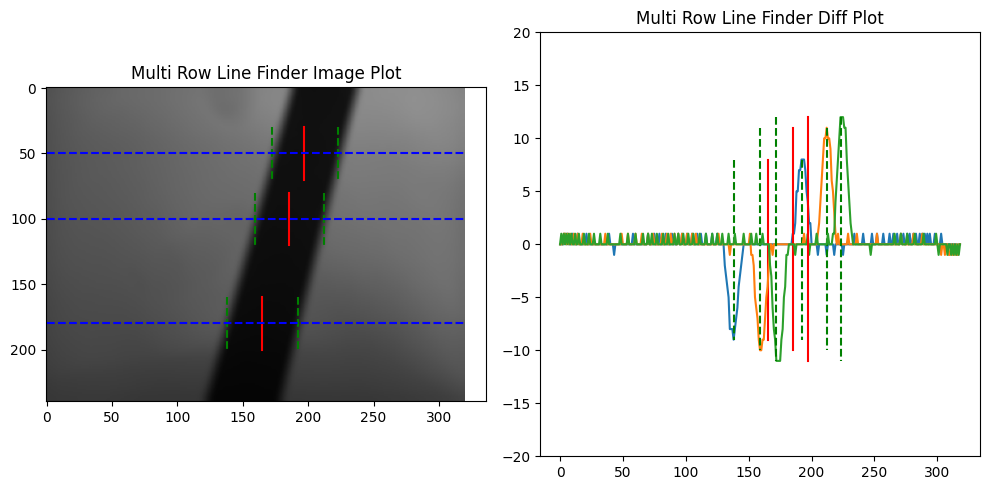

In [18]:
# Try detection on multiple rows
image = cv2.imread('line_2.jpg')
image = cv2.resize(image, (320, 240))
line = MultiRowLineFinder(image, [180, 100, 50])
line.plot_both()

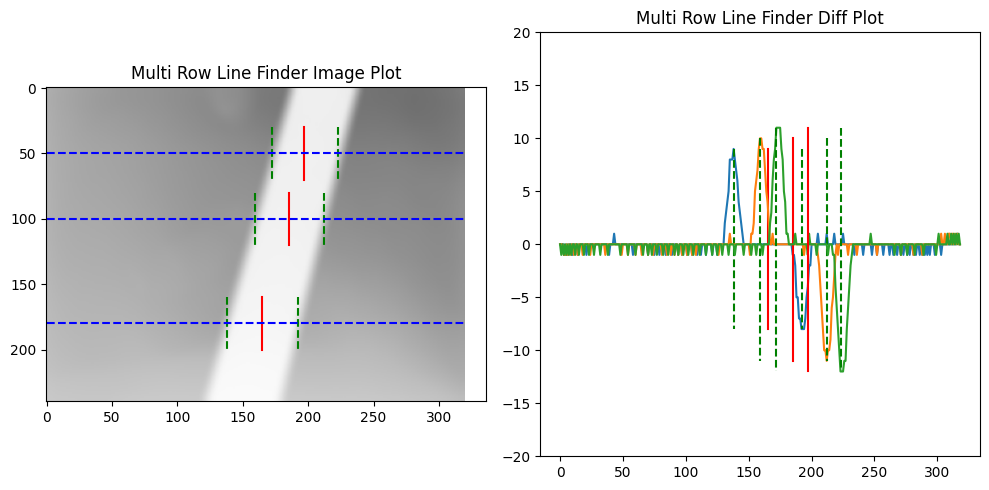

In [19]:
# Does this cope with an inverted image?
image = cv2.imread('line_2.jpg')
# Invert the image
image = cv2.resize(image, (320, 240))
image = cv2.bitwise_not(image)
line = MultiRowLineFinder(image, [180, 100, 50])
line.plot_both()

Research links:

- https://docs.opencv.org/4.x/d4/d13/tutorial_py_filtering.html


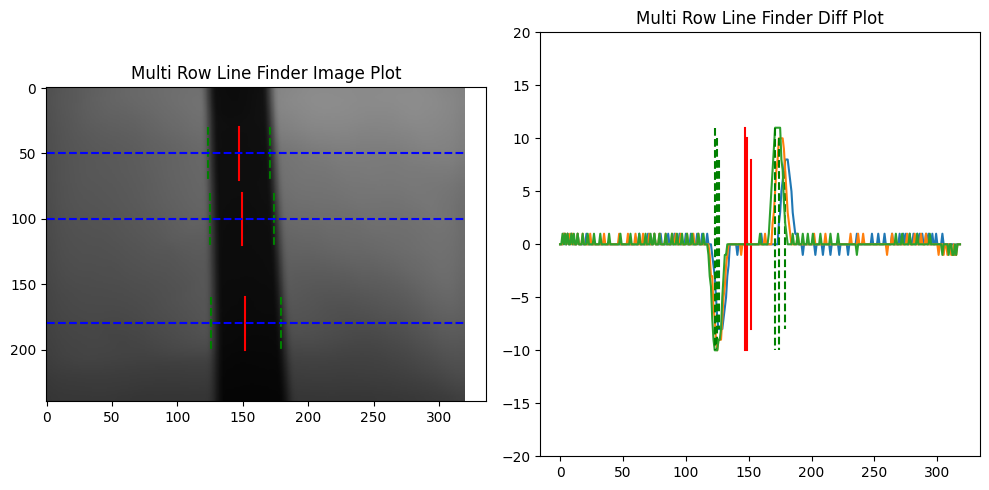

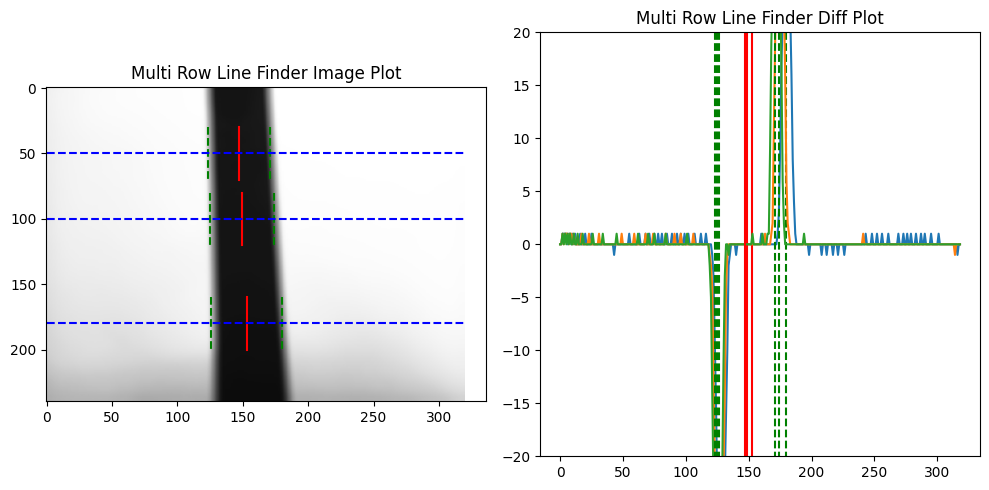

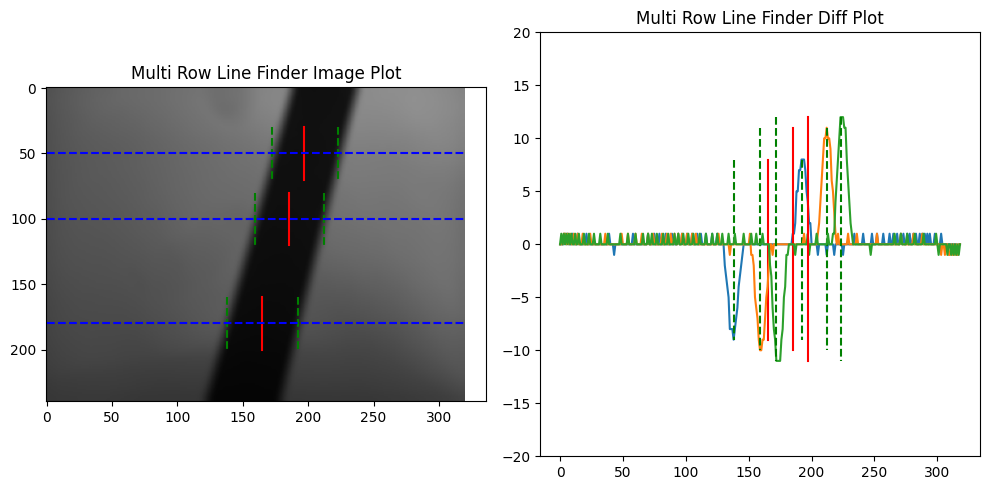

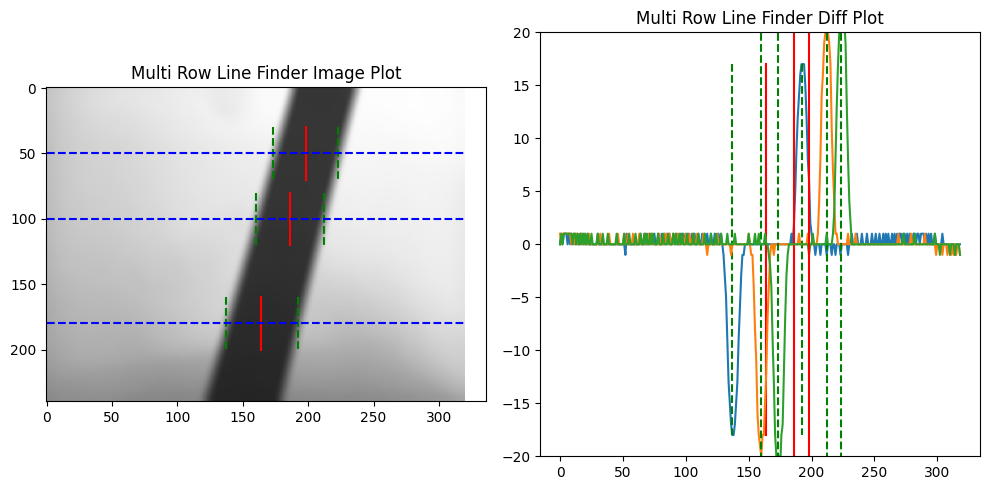

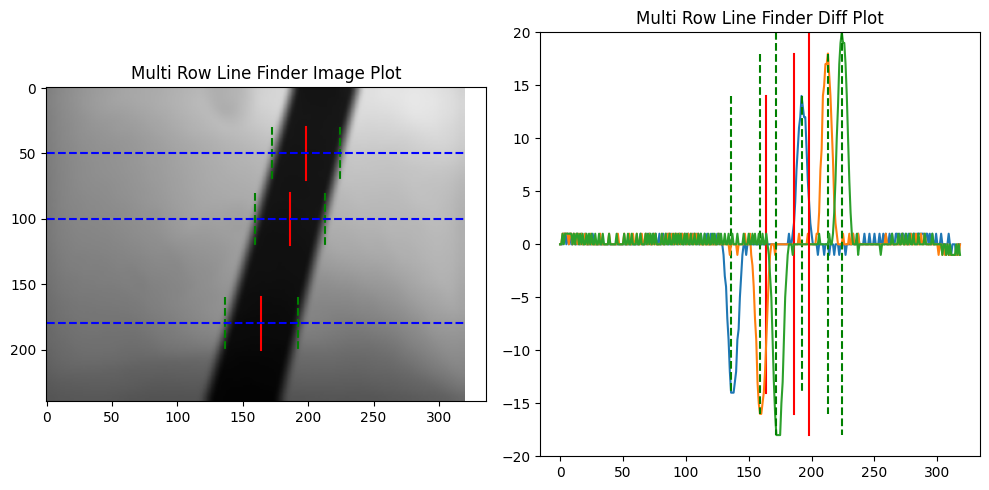

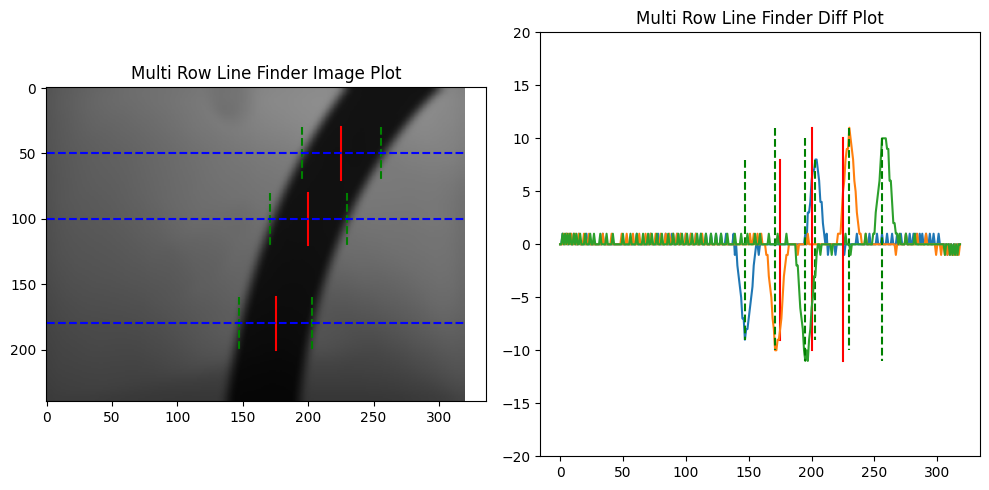

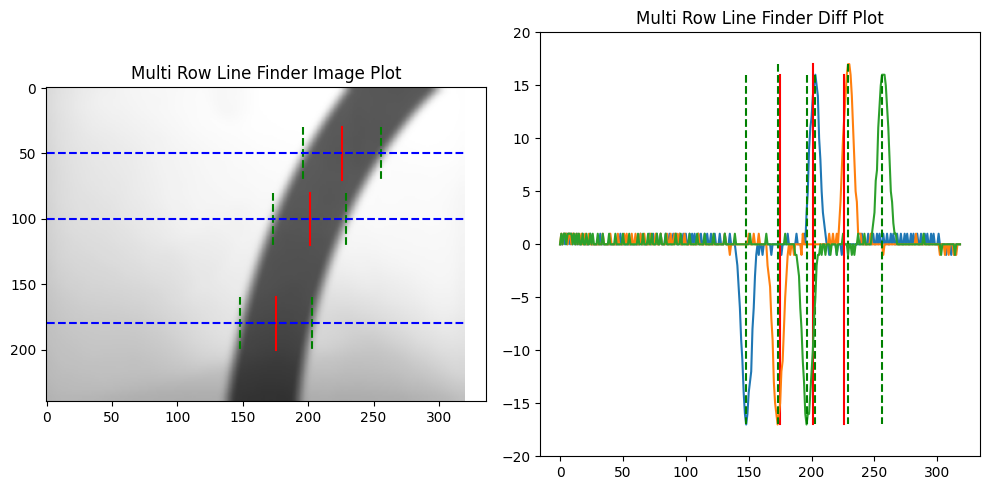

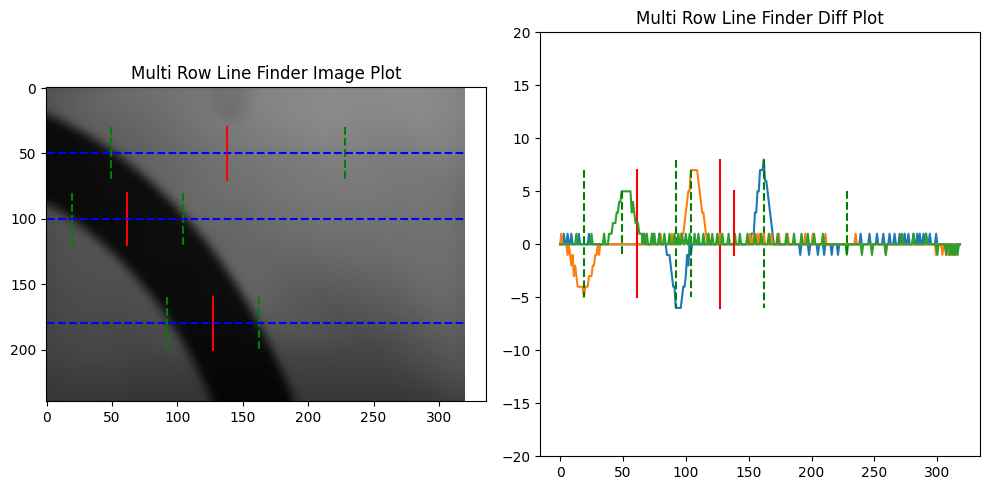

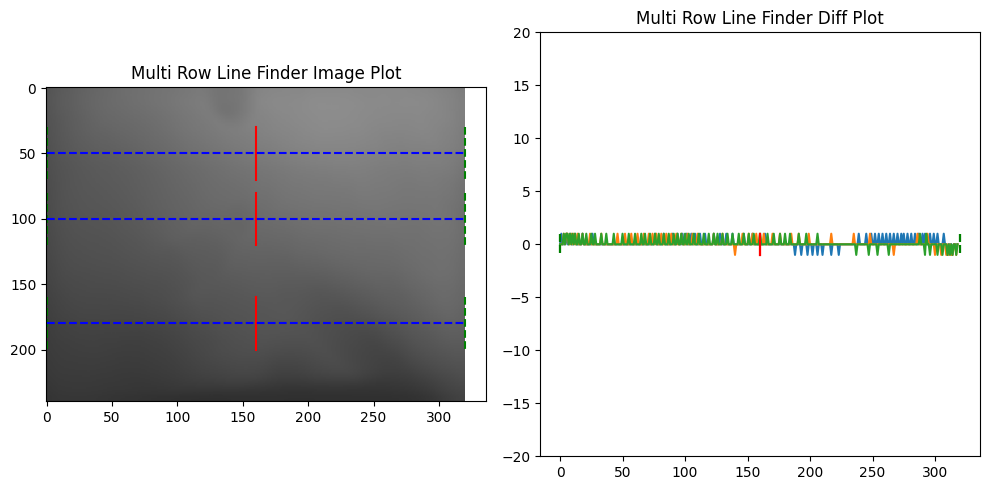

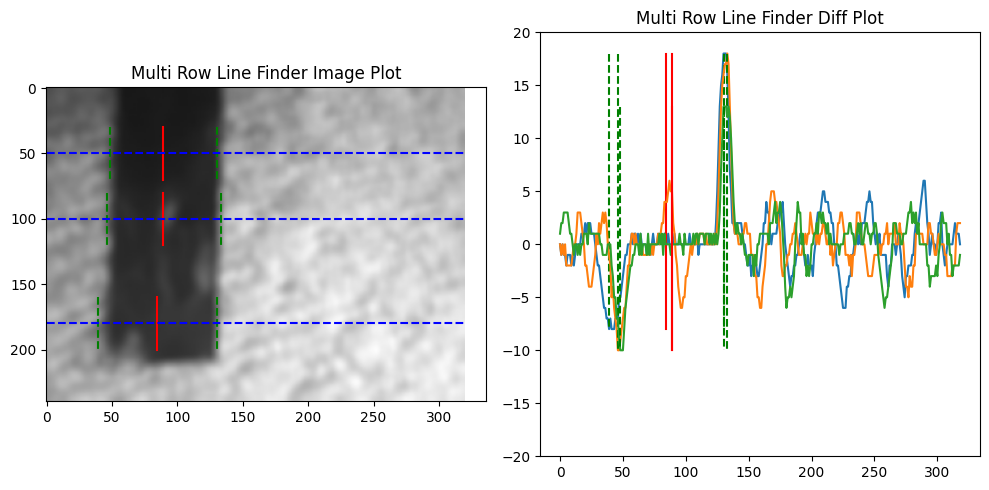

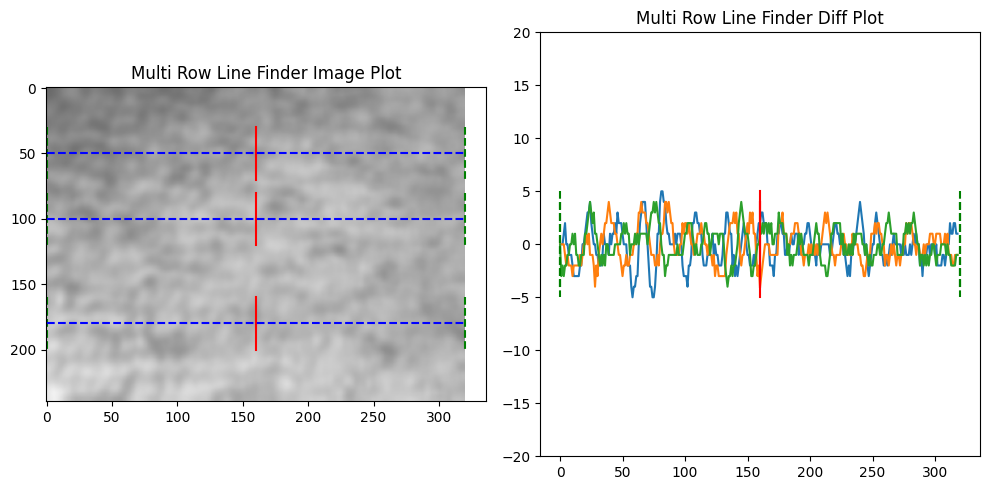

In [20]:
def try_line_image(image_path, row_numbers):
    image = cv2.imread(image_path)
    image = cv2.resize(image, (320, 240))
    line = MultiRowLineFinder(image, row_numbers)
    line.plot_both()

image_names = ['line_1.jpg', 'line_1_bright.jpg', 'line_2.jpg', 'line_2_bright.jpg', 'line_2_brighter.jpg', 'line_3.jpg', 'line_3_bright.jpg', 'line_4.jpg', 'line_5.jpg', 'carpet_line1 2.jpg', 'carpet_noline.jpg',
               ]
for image_name in image_names:
    try_line_image(image_name, [180, 100, 50])

Conclusion here - lets go with a row number, quite near to the front of the robot, and turn to ensure the identified middle of that row is in the horizontal middle of the camera view.

Hough lines, canny, other algorithms are not only more complicated, but with the image data set, are producing less useful results.